Идеи что поменять:
- Сделать сетку, а не просто 2 оси
- углубить модель
- нормализацию добавить

# Data

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

from data_generator import generate_dataset

In [10]:
device = torch.device("mps")

In [12]:
data = generate_dataset()
# data.to(device)

### Тренировочные данные (непрерывные)

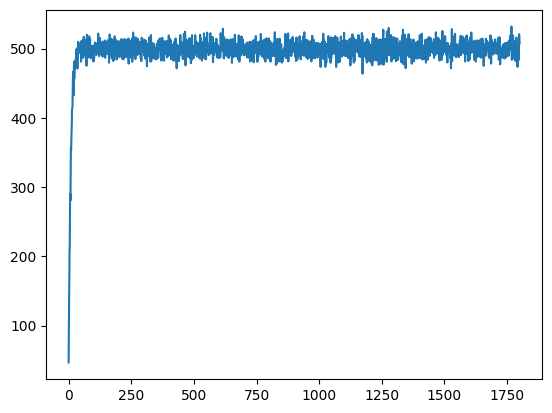

In [3]:
import matplotlib.pyplot as plt 
plt.plot(data['t_train'], data['S_train'])
plt.show()

### Тестовые данные (непрерывные)

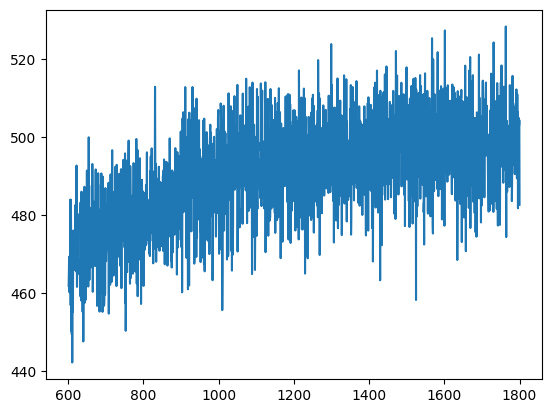

In [4]:
import matplotlib.pyplot as plt 
plt.plot(data['t_test'], data['S_test'])
plt.show()

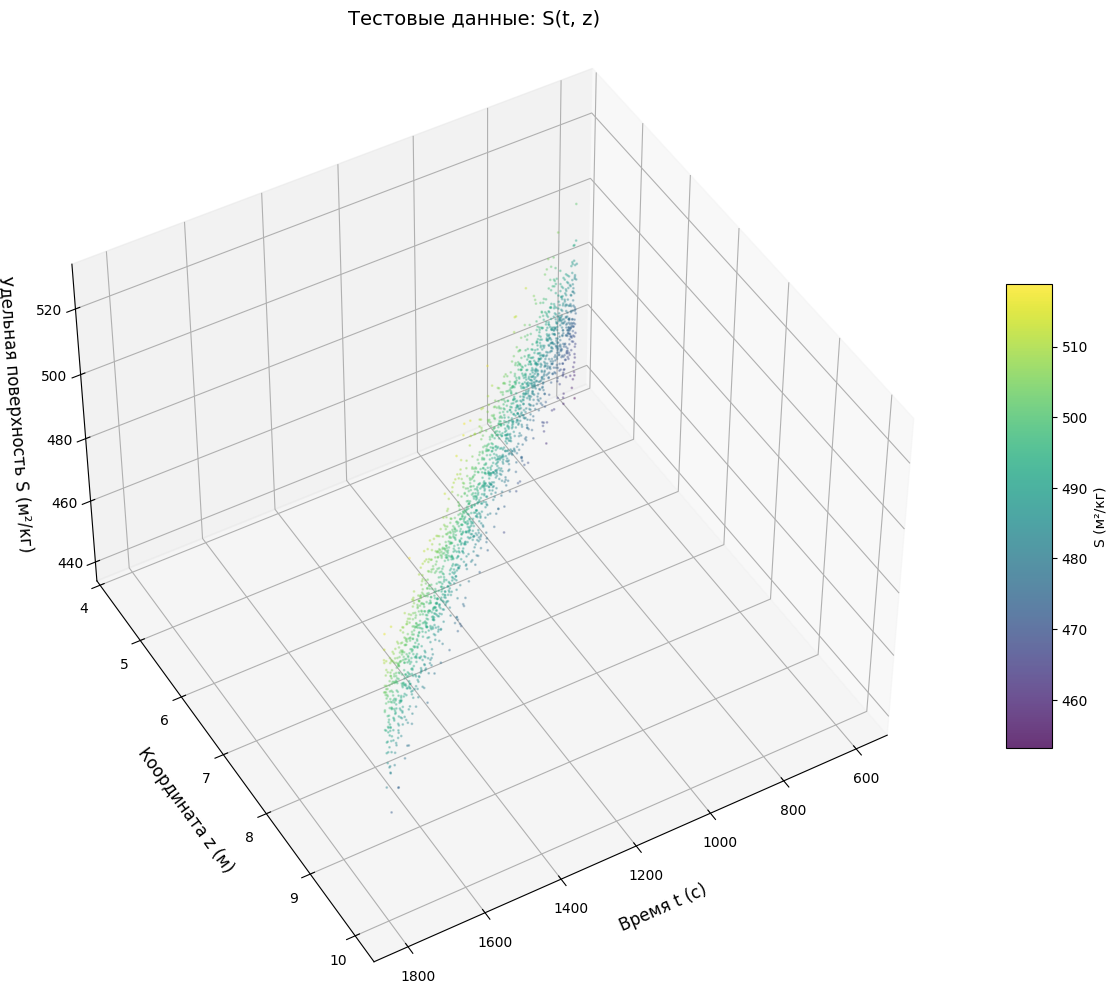

In [19]:
t_test = data['t_test'].detach().numpy().flatten()
z_test = data['z_test'].detach().numpy().flatten()
S_test = data['S_test'].detach().numpy().flatten()

# Создаем регулярную сетку для интерполяции
t_grid = np.linspace(t_test.min(), t_test.max(), 50)
z_grid = np.linspace(z_test.min(), z_test.max(), 50)
T, Z = np.meshgrid(t_grid, z_grid)

# Интерполируем данные на регулярную сетку
S_grid = griddata((t_test, z_test), S_test, (T, Z), method='cubic')

# Строим 3D поверхность
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Поверхность
surf = ax.plot_surface(T, Z, S_grid, cmap='viridis', alpha=0.8, 
                        linewidth=0, antialiased=True)

# Добавляем исходные точки
ax.scatter(t_test, z_test, S_test, c=S_test, cmap='viridis', 
            s=1, alpha=0.3, label='Данные')

# Настройка осей
ax.set_xlabel('Время t (с)', fontsize=12, labelpad=10)
ax.set_ylabel('Координата z (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Удельная поверхность S (м²/кг)', fontsize=12, labelpad=10)
ax.set_title('Тестовые данные: S(t, z)', fontsize=14, pad=20)

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='S (м²/кг)')

plt.tight_layout()
ax.view_init(elev=45,  
            azim=60)
plt.show()

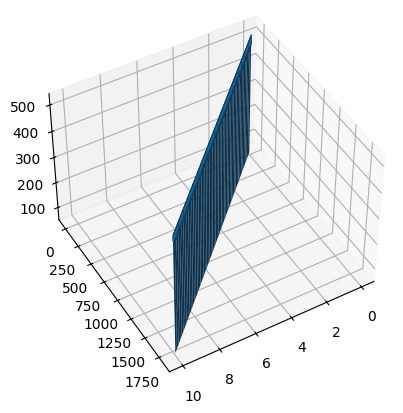

In [14]:
import matplotlib.pyplot as plt
z = data['z_train']
S = data['S_train']
t = data['t_train']
grid_x, grid_y = torch.meshgrid(z, t, indexing='ij')

ax = plt.axes(projection='3d')
ax.plot_surface(z.numpy(), t.numpy(), S.numpy())
ax.view_init(elev=45,  
            azim=60)
plt.show()


# PINN

In [ ]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.PINN import PINN
from loss.pinn_loss import pinn_loss

## PINN только с pde

## PINN, обученная с коэффициентами, которые мы задали

k = 0.12 <br>
v_m = 0.2 <br>
epochs = 30_000

### все параметры (включая mse)

 lambda_pde=2.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [25]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=2.,
        lambda_bc=1.,
        lambda_ic=1.,
        lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 332807.594
Epoch 100 | Loss: 316029.219
Epoch 200 | Loss: 299897.125
Epoch 300 | Loss: 284265.938
Epoch 400 | Loss: 269569.812
Epoch 500 | Loss: 256050.234
Epoch 600 | Loss: 243619.656
Epoch 700 | Loss: 231987.484
Epoch 800 | Loss: 220831.016
Epoch 900 | Loss: 209972.484
Epoch 1000 | Loss: 199432.109
Epoch 1100 | Loss: 189287.828
Epoch 1200 | Loss: 179491.344
Epoch 1300 | Loss: 170026.922
Epoch 1400 | Loss: 161014.078
Epoch 1500 | Loss: 152422.219
Epoch 1600 | Loss: 144151.297
Epoch 1700 | Loss: 136309.500
Epoch 1800 | Loss: 128803.555
Epoch 1900 | Loss: 121650.094
Epoch 2000 | Loss: 114840.078
Epoch 2100 | Loss: 108270.211
Epoch 2200 | Loss: 102039.578
Epoch 2300 | Loss: 96004.891
Epoch 2400 | Loss: 90298.523
Epoch 2500 | Loss: 84800.859
Epoch 2600 | Loss: 79381.125
Epoch 2700 | Loss: 74213.836
Epoch 2800 | Loss: 69394.531
Epoch 2900 | Loss: 64830.395
Epoch 3000 | Loss: 60499.348
Epoch 3100 | Loss: 56277.102
Epoch 3200 | Loss: 52237.867
Epoch 3300 

In [26]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse_pde.pth'))

### без MSE

lambda_pde=2.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=0.<br>

In [ ]:
pinn = PINN()
pinn.to(device)

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=100.,
        lambda_bc=1.,
        lambda_ic=1.,
        lambda_mse=0.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    S_pred = pinn(data['t_train'], data['z_train'])
    diff = data["S_train"] - S_pred

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | diff: {torch.mean(diff**2)}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 364404.969 | diff: 191900.796875
Epoch 100 | Loss: 348966.562 | diff: 183447.71875
Epoch 200 | Loss: 333613.219 | diff: 175342.140625
Epoch 300 | Loss: 318328.688 | diff: 167669.828125
Epoch 400 | Loss: 303636.438 | diff: 160330.25
Epoch 500 | Loss: 288505.062 | diff: 153966.359375
Epoch 600 | Loss: 273344.156 | diff: 148113.84375
Epoch 700 | Loss: 257592.875 | diff: 142273.21875
Epoch 800 | Loss: 240723.844 | diff: 137481.515625
Epoch 900 | Loss: 224700.172 | diff: 131925.234375
Epoch 1000 | Loss: 207763.641 | diff: 128393.2109375
Epoch 1100 | Loss: 191055.703 | diff: 123562.9609375
Epoch 1200 | Loss: 171298.656 | diff: 119936.703125
Epoch 1300 | Loss: 153094.719 | diff: 116500.796875
Epoch 1400 | Loss: 133703.281 | diff: 115247.34375
Epoch 1500 | Loss: 111679.547 | diff: 111430.3203125
Epoch 1600 | Loss: 94969.078 | diff: 110014.15625
Epoch 1700 | Loss: 74850.578 | diff: 108503.1484375
Epoch 1800 | Loss: 59555.723 | diff: 107184.828125
Epoch 1900 

In [7]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_pde.pth'))

### без pde

lambda_pde=0.,<br>
lambda_bc=1.,<br>
lambda_ic=1.,<br>
lambda_mse=2.<br>

In [14]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=0.,
        lambda_bc=1.,
        lambda_ic=1.,
        lambda_mse=2.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f}")

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 318366.000
Epoch 100 | Loss: 302149.125
Epoch 200 | Loss: 286507.875
Epoch 300 | Loss: 271402.312
Epoch 400 | Loss: 257283.281
Epoch 500 | Loss: 244337.859
Epoch 600 | Loss: 232464.688
Epoch 700 | Loss: 221522.422
Epoch 800 | Loss: 211316.859
Epoch 900 | Loss: 201641.625
Epoch 1000 | Loss: 192531.156
Epoch 1100 | Loss: 183967.812
Epoch 1200 | Loss: 175479.234
Epoch 1300 | Loss: 167036.891
Epoch 1400 | Loss: 158971.469
Epoch 1500 | Loss: 151039.859
Epoch 1600 | Loss: 143499.484
Epoch 1700 | Loss: 136337.922
Epoch 1800 | Loss: 128902.273
Epoch 1900 | Loss: 121669.320
Epoch 2000 | Loss: 114858.297
Epoch 2100 | Loss: 108355.633
Epoch 2200 | Loss: 102024.992
Epoch 2300 | Loss: 95688.867
Epoch 2400 | Loss: 89629.469
Epoch 2500 | Loss: 83557.109
Epoch 2600 | Loss: 77883.312
Epoch 2700 | Loss: 72551.758
Epoch 2800 | Loss: 67436.516
Epoch 2900 | Loss: 62649.484
Epoch 3000 | Loss: 58111.246
Epoch 3100 | Loss: 53755.211
Epoch 3200 | Loss: 49693.535
Epoch 3300 

In [15]:
torch.save({
    "model_state_dict": pinn.state_dict()
}, os.path.join('.', 'models', 'pinn_mse.pth'))

### Визуализация 3х моделей

In [6]:
# --- MSE PDE ---
pinn_mse_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse_pde.pth"))
pinn_mse_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_mse_pde.eval()

# --- MSE ---
pinn_mse = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_mse.pth"))
pinn_mse.load_state_dict(checkpoint["model_state_dict"])

pinn_mse.eval()

# --- PDE ---
pinn_pde = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn_pde.pth"))
pinn_pde.load_state_dict(checkpoint["model_state_dict"])

pinn_pde.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
)

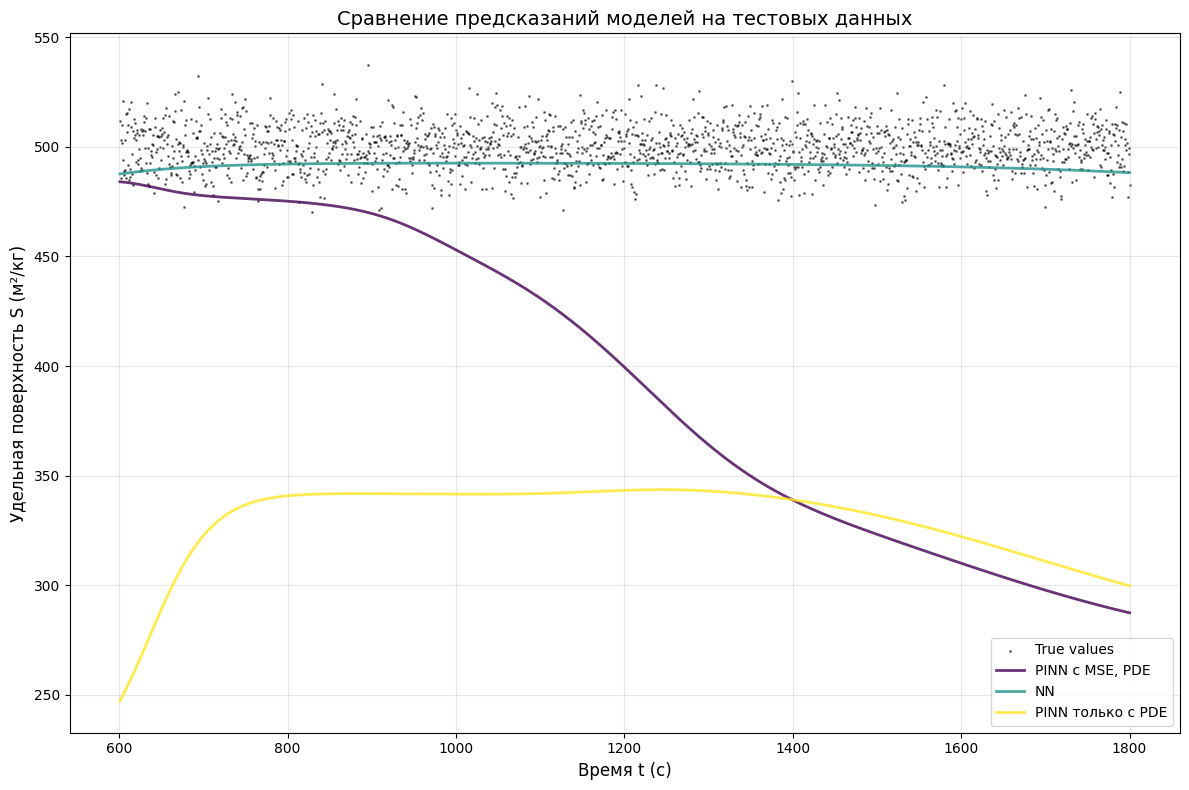

In [7]:
plt.figure(figsize=(12, 8))
t_test = data['t_test']
z_test = data['z_test']
S_test = data['S_test']
models = [pinn_mse_pde, pinn_mse, pinn_pde]
model_names = ['PINN с MSE, PDE', 'NN', 'PINN только с PDE']

# Строим истинные значения
plt.scatter(t_test, S_test, s=1, alpha=0.5, 
               color='black', label='True values')
    
# Строим предсказания каждой модели
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    S_pred = model(data['t_test'], data['z_test']).detach().numpy().flatten()
    plt.plot(t_test, S_pred, linewidth=2, 
                color=colors[i], label=name, alpha=0.8)

plt.xlabel('Время t (с)', fontsize=12)
plt.ylabel('Удельная поверхность S (м²/кг)', fontsize=12)
plt.title('Сравнение предсказаний моделей на тестовых данных', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


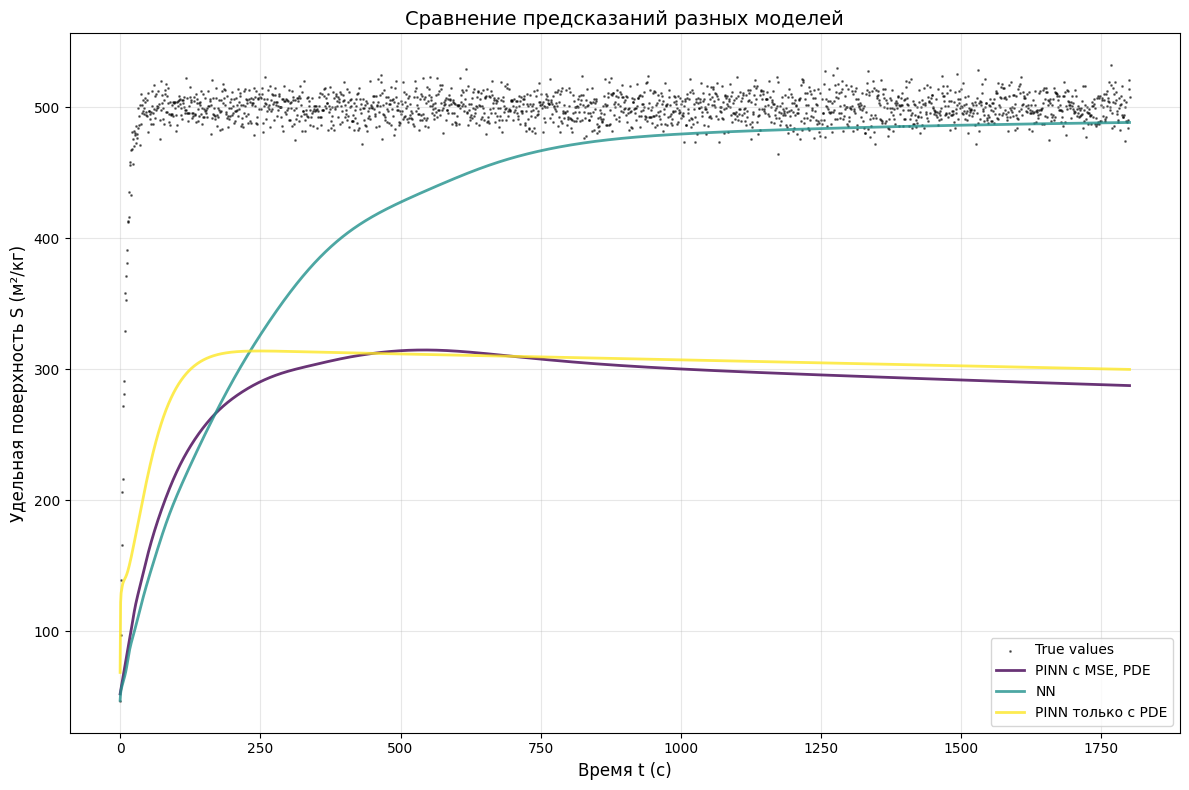

In [8]:
plt.figure(figsize=(12, 8))
t_test = data['t_train'].detach().numpy().flatten()
z_test = data['z_train'].detach().numpy().flatten()
S_test = data['S_train'].detach().numpy().flatten()
models = [pinn_mse_pde, pinn_mse, pinn_pde]
model_names = ['PINN с MSE, PDE', 'NN', 'PINN только с PDE']

# Строим истинные значения
plt.scatter(t_test, S_test, s=1, alpha=0.5, 
               color='black', label='True values')
    
# Строим предсказания каждой модели
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for i, (model, name) in enumerate(zip(models, model_names)):
    S_pred = model(data['t_train'], data['z_train']).detach().numpy().flatten()
    plt.plot(t_test, S_pred, linewidth=2, 
                color=colors[i], label=name, alpha=0.8)

plt.xlabel('Время t (с)', fontsize=12)
plt.ylabel('Удельная поверхность S (м²/кг)', fontsize=12)
plt.title('Сравнение предсказаний разных моделей', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [35]:
S_pred = pinn_pde(data['t_train'], data['z_train'])

In [36]:
S_pred-data['S_train']

tensor([[   0.7327],
        [  -3.4039],
        [   4.0379],
        ...,
        [-417.2485],
        [-427.8055],
        [-423.6121]], grad_fn=<SubBackward0>)

## PINN с MSE и обучаемыми параметрами

Обучение PINN с MSE и обучаемым параметром k

In [10]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []
parametr_k = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(30_000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_train"], data["z_train"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        t_real=data["t_train"], z_real=data["z_train"], S_real=data["S_train"],
        lambda_pde=1.,
        lambda_bc=1.,
        lambda_ic=1.,
        lambda_mse=1000.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())
    parametr_k.append(pinn.k.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k: {pinn.k.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 157385504.000 | k: 0.999
Epoch 100 | Loss: 149573840.000 | k: 0.902
Epoch 200 | Loss: 142293504.000 | k: 0.811
Epoch 300 | Loss: 135312896.000 | k: 0.727
Epoch 400 | Loss: 128621528.000 | k: 0.649
Epoch 500 | Loss: 122208536.000 | k: 0.578
Epoch 600 | Loss: 116063632.000 | k: 0.513
Epoch 700 | Loss: 110177048.000 | k: 0.454
Epoch 800 | Loss: 104539488.000 | k: 0.400
Epoch 900 | Loss: 99141816.000 | k: 0.352
Epoch 1000 | Loss: 93974008.000 | k: 0.308
Epoch 1100 | Loss: 89018144.000 | k: 0.270
Epoch 1200 | Loss: 84268480.000 | k: 0.235
Epoch 1300 | Loss: 79719960.000 | k: 0.204
Epoch 1400 | Loss: 75366136.000 | k: 0.177
Epoch 1500 | Loss: 71199632.000 | k: 0.153
Epoch 1600 | Loss: 67214176.000 | k: 0.132
Epoch 1700 | Loss: 63403480.000 | k: 0.114
Epoch 1800 | Loss: 59761532.000 | k: 0.098
Epoch 1900 | Loss: 56282564.000 | k: 0.084
Epoch 2000 | Loss: 52961092.000 | k: 0.073
Epoch 2100 | Loss: 49791840.000 | k: 0.063
Epoch 2200 | Loss: 46769752.000 | k:

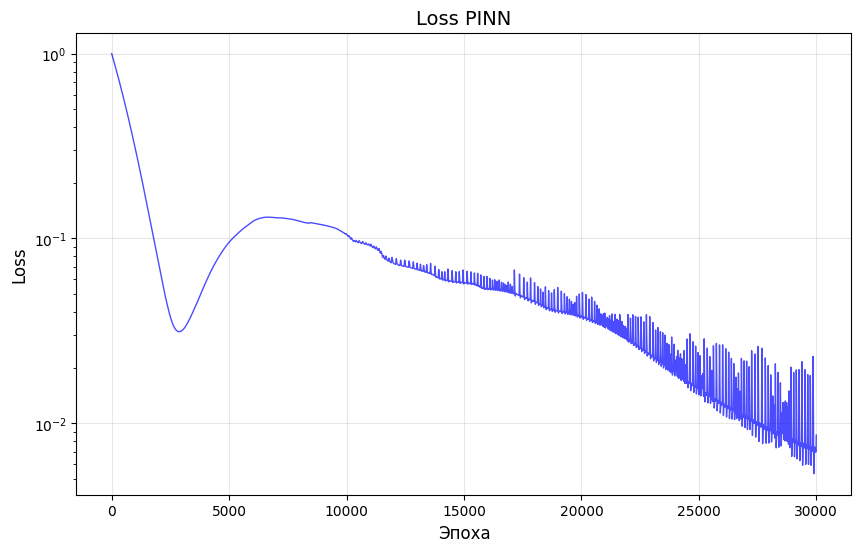

In [11]:
import matplotlib.pyplot as plt

def plot_loss(history):
    """
    Построение графика функции потерь
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history, linewidth=1, color='blue', alpha=0.7)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss PINN', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log') 
    # plt.tight_layout()
    plt.show()

# Вызов после обучения
plot_loss(parametr_k)

# MDN

In [ ]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from networks.MDN import MDN
from loss.mdn_loss import mdn_loss

In [6]:
pinn = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn.pth"))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [96]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    # Gaussian PDF
    coeff = 1.0 / (sigma * torch.sqrt(torch.tensor(2.0 * torch.pi)))
    exponent = torch.exp(-0.5 * ((target - mu) / sigma)**2)

    probs = coeff * exponent
    weighted = pi * probs

    # weighted имеет форму (batch_size, n_components)
    sum_over_components = torch.sum(weighted, dim=1)  # форма (batch_size,)
    print(sum_over_components.shape)



    # loss = -torch.log(sum_over_components + 1e-8)      # форма (batch_size,)
    

    loss = -torch.log(torch.sum(weighted) + 1e-6)
    loss = torch.mean(loss)           # скаляр
    
    return loss

In [14]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    log_probs = -0.5 * ((target - mu) / sigma)**2 \
                - torch.log(sigma) \
                - 0.5 * math.log(2 * math.pi)

    log_weighted = torch.log(pi) + log_probs
    # print(log_weighted)

    loss = -torch.logsumexp(log_weighted, dim=1)
    return loss.mean()

In [16]:
mdn = MDN()

optimizer = optim.Adam(mdn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ MDN')
for epoch in range(30000):
    mdn.train()
    optimizer.zero_grad()

    pi, mu, sigma = mdn.forward(S_pred)

    loss = mdn_loss(pi, mu, sigma, data['S_train'])

    
    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

НАЧАЛО ОБУЧЕНИЯ MDN
Epoch 0 | Loss: 126362.007812
Epoch 100 | Loss: 2331.195557
Epoch 200 | Loss: 1534.125732
Epoch 300 | Loss: 1152.785156
Epoch 400 | Loss: 928.347900
Epoch 500 | Loss: 779.304688
Epoch 600 | Loss: 672.390686
Epoch 700 | Loss: 591.509949
Epoch 800 | Loss: 527.907715
Epoch 900 | Loss: 476.399139
Epoch 1000 | Loss: 433.711487
Epoch 1100 | Loss: 397.670898
Epoch 1200 | Loss: 366.774261
Epoch 1300 | Loss: 339.947815
Epoch 1400 | Loss: 316.401825
Epoch 1500 | Loss: 295.542908
Epoch 1600 | Loss: 276.914612
Epoch 1700 | Loss: 260.161499
Epoch 1800 | Loss: 245.001053
Epoch 1900 | Loss: 231.205948
Epoch 2000 | Loss: 218.591797
Epoch 2100 | Loss: 207.006592
Epoch 2200 | Loss: 196.323990
Epoch 2300 | Loss: 186.438248
Epoch 2400 | Loss: 177.260193
Epoch 2500 | Loss: 168.713791
Epoch 2600 | Loss: 160.734100
Epoch 2700 | Loss: 153.264999
Epoch 2800 | Loss: 146.257935
Epoch 2900 | Loss: 139.670624
Epoch 3000 | Loss: 133.465942
Epoch 3100 | Loss: 127.611481
Epoch 3200 | Loss: 122.078

In [29]:
torch.save({
    "model_state_dict": mdn.state_dict()
}, os.path.join('.', 'models', 'mdn.pth'))

In [13]:
mdn = MDN()

checkpoint = torch.load(os.path.join('.', 'models', "mdn.pth"))
mdn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

mdn.eval()

MDN(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
  )
  (pi): Linear(in_features=100, out_features=3, bias=True)
  (mu): Linear(in_features=100, out_features=3, bias=True)
  (sigma): Linear(in_features=100, out_features=3, bias=True)
)

In [17]:
mdn.predict(S_pred)

(tensor([378.8259, 378.8259, 378.8259,  ..., 378.8259, 378.8259, 378.8259]),
 tensor([151.4041, 151.4041, 151.4041,  ..., 151.4041, 151.4041, 151.4041]),
 tensor([606.2477, 606.2477, 606.2477,  ..., 606.2477, 606.2477, 606.2477]))

In [18]:
mean, lower, upper = mdn.predict(S_pred)

# График

In [19]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_mdn_results(model, x, y_true, pinn_pred, title):
    model.eval()

    # сортировка для красивой линии
    x_sorted, indices = torch.sort(x.squeeze())
    y_true_sorted = y_true.squeeze()[indices]

    # MDN предсказания
    mean, lower, upper = model.predict(x)

    mean = mean[indices]
    lower = lower[indices]
    upper = upper[indices]

    # === plotting ===
    plt.figure(figsize=(8, 5))

    # реальные данные
    plt.scatter(x_sorted.cpu(), y_true_sorted.cpu(),
                s=10, alpha=0.5, label="Data")

    # PINN (если есть)
    if pinn_pred is not None:
        pinn_pred = pinn_pred.squeeze()[indices]
        plt.plot(x_sorted.cpu(), pinn_pred.cpu(),
                 linestyle="--", label="PINN")

    # MDN mean
    plt.plot(x_sorted.cpu(), mean.cpu(),
             linewidth=2, label="MDN mean")

    # uncertainty band
    plt.fill_between(
        x_sorted.cpu().numpy(),
        lower.cpu().numpy(),
        upper.cpu().numpy(),
        alpha=0.3,
        label="MDN ±1.96σ"
    )
    
    plt.xlabel(title)
    plt.ylabel("S")
    plt.legend()
    plt.title("MDN uncertainty visualization")

    plt.tight_layout()
    plt.show()

In [20]:
plot_mdn_results(
    model=mdn,
    x=data['t_train'],
    y_true=data['S_train'],
    pinn_pred=S_pred,
    title='t'
)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2000 and 1x100)

In [20]:
plot_mdn_results(
    model=mdn,
    x=data['z_train'],
    y_true=data['S_train'],
    pinn_pred=S_pred,
    title='z'
)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1000 and 1x100)